# Multi-Source Data Consolidation


**Objective:** Ingest inconsistent public data sources, document quality gaps, apply transformation logic, and build a decision-grade dashboard.

## Task List

- Imports
- Download List
- Download Code
- Rewrite Download Code Cell 
- What is  module in Python




# Data Source List

1. [Bank Of England: Interest Rates and Lending Data](https://www.bankofengland.co.uk/boeapps/iadb/)
   + Official Bank Rate (monthly)
   + Mortgage Approvals
   + Consumer Credit (net lending)
   + SME Net Lending
2. [Office of National Statistics(ONS)](https://www.ons.gov.uk/economy/inflationandpriceindices/datalist)
   + CPI Inflation (Annual %)
   + GDP Growth (QoQ %)
   + Unemployment Rate
   + Average Weekly Earnings
3. [UK House Price Index (HM Land Registry + ONS)](https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-january-2025)
   + UK HPI Full File** (all regions, all metrics)
   + Average House Price UK only
4. [FCA: Financial Services Complaints](https://www.fca.org.uk/data/financial-services-complaints-data)
   + Complaints Data H1 2024



In [14]:
# ── Import Libraries  ────────────────────────────────────────────────────────────────

import pandas as pd
import requests
import time
from pathlib import Path
from datetime import datetime

# ── Config ────────────────────────────────────────────────────────────────

# Anchor all paths to the notebook's own directory so they work regardless
# of what the kernel's working directory is set to.
NOTEBOOK_DIR = Path(__vsc_ipynb_file__).parent       # .../multi/

DATA_ROOT   = NOTEBOOK_DIR / 'data'                  # .../multi/data/
CONFIG_FILE = DATA_ROOT / 'config' / 'data_sources.csv'

DELAY_S   = 2      # delay between requests (seconds)
TIMEOUT_S = 60     # per-file timeout
OVERWRITE = False  # set True to re-download files that already exist

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (compatible; DataAnalytics/1.0; public data research)',
    'Accept':     'text/csv, text/plain, application/octet-stream, */*',
}
# ──────────────────────────────────────────────────────────────────────────

sources = pd.read_csv(CONFIG_FILE)
print(f'Loaded {len(sources)} sources from {CONFIG_FILE}')
sources[['source', 'series_label', 'folder', 'filename']]

Loaded 12 sources from /home/paul/gnotes/Projects/Blog/content/python/multi/data/config/data_sources.csv


,source,series_label,folder,filename
0,Bank of England,base_rate,raw/boe,boe_base_rate.csv
1,Bank of England,mortgage_approvals,raw/boe,boe_mortgage_approvals.csv
2,Bank of England,consumer_credit,raw/boe,boe_consumer_credit.csv
3,Bank of England,sme_lending,raw/boe,boe_sme_lending.csv
4,ONS,cpi_inflation,raw/ons,ons_cpi_inflation.csv
5,ONS,gdp_growth,raw/ons,ons_gdp_growth.csv
6,ONS,unemployment_rate,raw/ons,ons_unemployment.csv
7,ONS,avg_weekly_earnings,raw/ons,ons_avg_weekly_earnings.csv
8,hpi,full_dataset,CSV,hpi_full_dataset.csv
9,FRED,gilt_10yr,raw/fred,fred_gilt_10yr.csv


In [15]:
# ── Download All Data Sources ─────────────────────────────────────────────────────────

results = []

for _, row in sources.iterrows():
    dest_dir  = DATA_ROOT / row['folder']   # raw/<source> as defined in config
    dest_file = dest_dir / row['filename']

    # ── Skip if file already exists and OVERWRITE is disabled ────────────
    if dest_file.exists() and not OVERWRITE:
        print(f'[SKIP]  {row["series_label"]:30s}  →  {dest_file}')
        results.append({
            'source': row['source'], 'series_label': row['series_label'],
            'filename': row['filename'], 'folder': row['folder'],
            'status': 'SKIPPED', 'size_kb': None, 'error': None, 'path': str(dest_file),
        })
        continue

    # ── Create destination directory if it doesn't exist ────────────────
    dest_dir.mkdir(parents=True, exist_ok=True)

    try:
        print(f'[GET]   {row["series_label"]:30s}  →  {dest_file}')
        response = requests.get(row['url'], headers=HEADERS, timeout=TIMEOUT_S)
        response.raise_for_status()

        # Write raw bytes so binary formats (xlsx, zip) are preserved
        dest_file.write_bytes(response.content)

        size_kb = round(len(response.content) / 1024, 1)
        print(f'        ✓  {size_kb} KB saved')
        results.append({
            'source': row['source'], 'series_label': row['series_label'],
            'filename': row['filename'], 'folder': row['folder'],
            'status': 'OK', 'size_kb': size_kb, 'error': None, 'path': str(dest_file),
        })

    except requests.HTTPError as e:
        print(f'        ✗  HTTP error: {e}')
        results.append({
            'source': row['source'], 'series_label': row['series_label'],
            'filename': row['filename'], 'folder': row['folder'],
            'status': 'HTTP_ERROR', 'size_kb': None, 'error': str(e), 'path': '',
        })

    except requests.RequestException as e:
        print(f'        ✗  Request failed: {e}')
        results.append({
            'source': row['source'], 'series_label': row['series_label'],
            'filename': row['filename'], 'folder': row['folder'],
            'status': 'FAILED', 'size_kb': None, 'error': str(e), 'path': '',
        })

    # ── Polite delay between requests to avoid rate-limiting ─────────────
    time.sleep(DELAY_S)

# ── Summary ──────────────────────────────────────────────────────────────

summary = pd.DataFrame(results)[['source', 'series_label', 'filename', 'status', 'size_kb', 'error']]

ok      = (summary['status'] == 'OK').sum()
skipped = (summary['status'] == 'SKIPPED').sum()
failed  = summary[~summary['status'].isin(['OK', 'SKIPPED'])]

print(f'── Download Summary ───────────────────────')
print(f'  ✅  Downloaded : {ok}')
print(f'  ⏭️  Skipped    : {skipped}')
print(f'  ❌  Failed     : {len(failed)}')

if not failed.empty:
    print('\nFailed — check URLs in config/data_sources.csv:')
    display(failed[['series_label', 'status', 'error']])

# ── Save audit log → data/logs/ ──────────────────────────────────────────
log = pd.DataFrame(results)[['source', 'series_label', 'filename', 'folder', 'status', 'size_kb', 'error', 'path']]
log['downloaded_at'] = datetime.now().strftime('%Y-%m-%d %H:%M')
(DATA_ROOT / 'logs').mkdir(parents=True, exist_ok=True)
log.to_csv(DATA_ROOT / 'logs' / 'download_log.csv', index=False)
print(f'\nDownload log saved → data/logs/download_log.csv')

display(summary)

[SKIP]  base_rate                       →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/boe/boe_base_rate.csv
[SKIP]  mortgage_approvals              →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/boe/boe_mortgage_approvals.csv
[SKIP]  consumer_credit                 →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/boe/boe_consumer_credit.csv
[SKIP]  sme_lending                     →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/boe/boe_sme_lending.csv
[SKIP]  cpi_inflation                   →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/ons/ons_cpi_inflation.csv
[SKIP]  gdp_growth                      →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/ons/ons_gdp_growth.csv
[SKIP]  unemployment_rate               →  /home/paul/gnotes/Projects/Blog/content/python/multi/data/raw/ons/ons_unemployment.csv
[SKIP]  avg_weekly_earnings             →  /home/paul/gnotes/Projects/Blog/content/pyt

,source,series_label,filename,status,size_kb,error
0,Bank of England,base_rate,boe_base_rate.csv,SKIPPED,NaN,None
1,Bank of England,mortgage_approvals,boe_mortgage_approvals.csv,SKIPPED,NaN,None
2,Bank of England,consumer_credit,boe_consumer_credit.csv,SKIPPED,NaN,None
3,Bank of England,sme_lending,boe_sme_lending.csv,SKIPPED,NaN,None
4,ONS,cpi_inflation,ons_cpi_inflation.csv,SKIPPED,NaN,None
5,ONS,gdp_growth,ons_gdp_growth.csv,SKIPPED,NaN,None
6,ONS,unemployment_rate,ons_unemployment.csv,SKIPPED,NaN,None
7,ONS,avg_weekly_earnings,ons_avg_weekly_earnings.csv,SKIPPED,NaN,None
8,hpi,full_dataset,hpi_full_dataset.csv,OK,32121.0,None
9,FRED,gilt_10yr,fred_gilt_10yr.csv,SKIPPED,NaN,None


# SECTION 2 · Data Quality Checklist

Run these checks on **every** series as you ingest it. Fill in the table below.

### Quality Grade Definitions
| Grade | Criteria | Decision |
|-------|----------|----------|
| **A** | <1% nulls, no gaps, no anomalies | Decision-ready |
| **B** | 1–5% nulls or minor gaps | Usable with documented caveats |
| **C** | 5–20% nulls or structural issues | Use with caution, apply imputation |
| **FAIL** | >20% nulls or empty | Do not use — find alternative |

### Quality Log (fill this in as you go)

| Series | Source | Rows | Null % | Date Range | Gaps | Anomalies | Grade | Decision / Action |
|--------|--------|------|--------|------------|------|-----------|-------|-------------------|
| base_rate | BoE | | | | | | | |
| mortgage_approvals | BoE | | | | | | | |
| consumer_credit | BoE | | | | | | | |
| sme_lending | BoE | | | | | | | |
| cpi_inflation | ONS | | | | | | | |
| gdp_growth | ONS | | | | | | | |
| unemployment | ONS | | | | | | | |
| avg_earnings | ONS | | | | | | | |
| hpi_avg_price | HPI | | | | | | | |
| hpi_sales_volume | HPI | | | | | | | |
| gilt_10yr | FRED | | | | | | | |
| gbp_usd | FRED | | | | | | | |

### Key Checks to Run Per Series
```python
# After loading a dataframe `df` with columns [date, value]:

print(df.shape)                          # Row count
print(df['value'].isna().mean())         # Null %
print(df['date'].min(), df['date'].max()) # Date range
print(df['date'].duplicated().sum())     # Duplicate dates
print(df.dtypes)                         # Type check
df['value'].describe()                   # Distribution
df.plot(x='date', y='value')             # Visual sanity check
```


── base_rate (BoE) ──────────────────────
  Rows: 300  |  Nulls: 0.0%  |  Range: 2000-01 → 2024-12
  Gaps: 0  |  Duplicates: 0  |  Grade: A
count    300.000000
mean       2.395879
std        2.182405
min        0.100000
25%        0.500000
50%        0.750000
75%        4.732975
max        6.000000


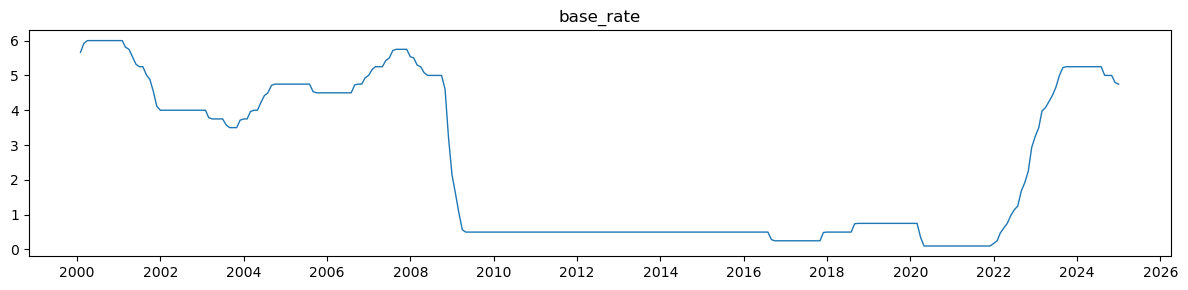


── mortgage_approvals (BoE) ──────────────────────
  Rows: 96  |  Nulls: 0.0%  |  Range: 2000-01 → 2007-12
  Gaps: 0  |  Duplicates: 0  |  Grade: A
count       96.000000
mean      9463.677083
std       2841.102745
min       4796.000000
25%       6719.250000
50%       9661.000000
75%      12089.250000
max      15120.000000


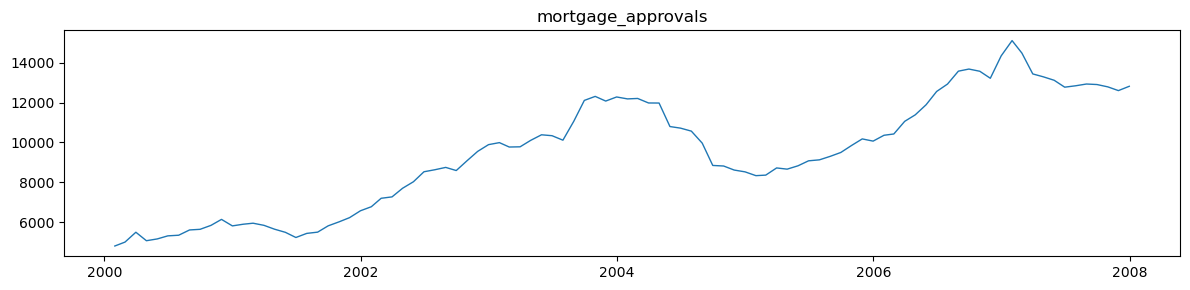


── consumer_credit (BoE) ──────────────────────
  Rows: 300  |  Nulls: 0.0%  |  Range: 2000-01 → 2024-12
  Gaps: 0  |  Duplicates: 0  |  Grade: A
count      300.000000
mean     14426.406667
std       2395.332971
min       8374.000000
25%      12327.750000
50%      14137.500000
75%      15947.000000
max      20512.000000


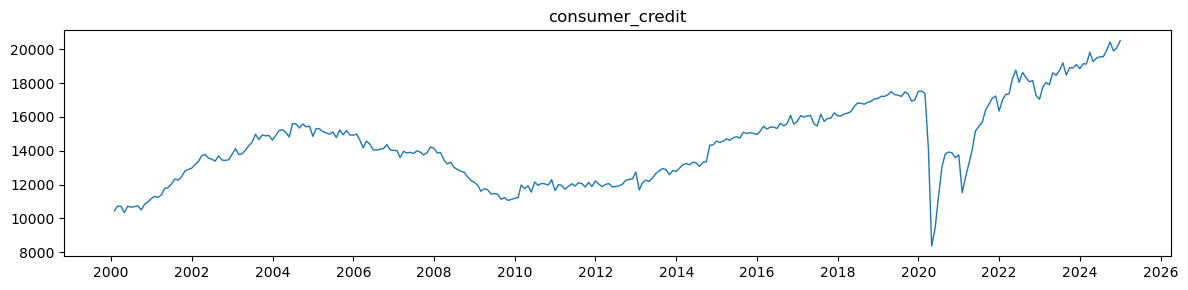

[WARN] Skipping sme_lending: no DATE header found.
[WARN] cpi_inflation: could not detect data start — first 10 lines:
"Title","CPIH ANNUAL RATE 00: ALL ITEMS 2015=100"
"CDID","L55O"
"Source dataset ID","MM23"
"PreUnit",""
"Unit","%"
"Release date","18-02-2026"
"Next release","25 March 2026"
"Important notes",
"1989","5.7"
"1990","8.0"
[WARN] gdp_growth: could not detect data start — first 10 lines:
"Title","Gross Domestic Product: Quarter on Quarter growth: CVM SA %"
"CDID","IHYQ"
"Source dataset ID","PN2"
"PreUnit",""
"Unit","%"
"Release date","12-02-2026"
"Next release","31 March 2026"
"Important notes",""
"1955 Q2","0.1"
"1955 Q3","1.7"
[WARN] unemployment_rate: could not detect data start — first 10 lines:
"Title","Unemployment rate (aged 16 and over, seasonally adjusted): %"
"CDID","MGSX"
"Source dataset ID","LMS"
"PreUnit",""
"Unit","%"
"Release date","17-02-2026"
"Next release","19 March 2026"
"Important notes",
"1971","4.1"
"1972","4.3"
[WARN] avg_weekly_earnings: could not de

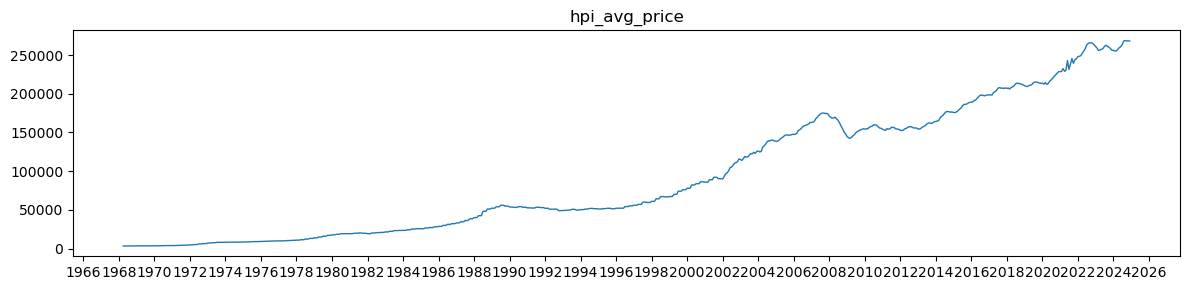


── hpi_sales_volume (HPI) ──────────────────────
  Rows: 681  |  Nulls: 65.05%  |  Range: 1968-04 → 2024-12
  Gaps: 0  |  Duplicates: 0  |  Grade: FAIL
count       238.000000
mean      81742.634454
std       24564.093899
min       28361.000000
25%       65867.500000
50%       77972.500000
75%       94369.500000
max      183609.000000


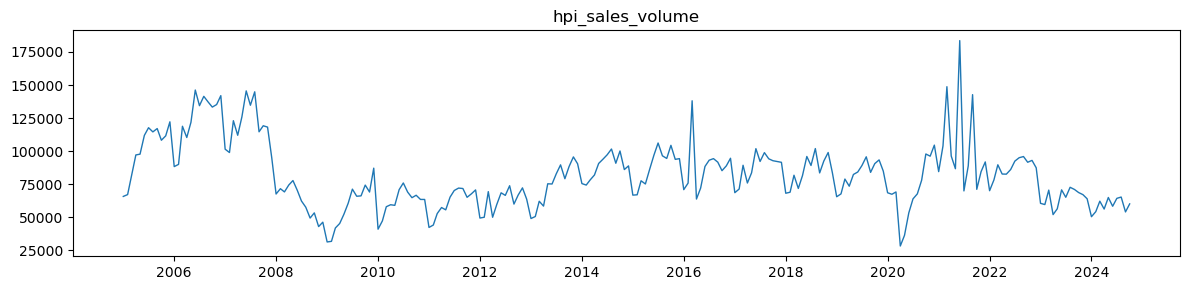


── gilt_10yr (FRED) ──────────────────────
  Rows: 793  |  Nulls: 0.0%  |  Range: 1960-01 → 2026-01
  Gaps: 0  |  Duplicates: 0  |  Grade: A
count    793.000000
mean       6.926861
std        3.858050
min        0.209400
25%        4.317700
50%        6.373900
75%        9.780000
max       16.340000


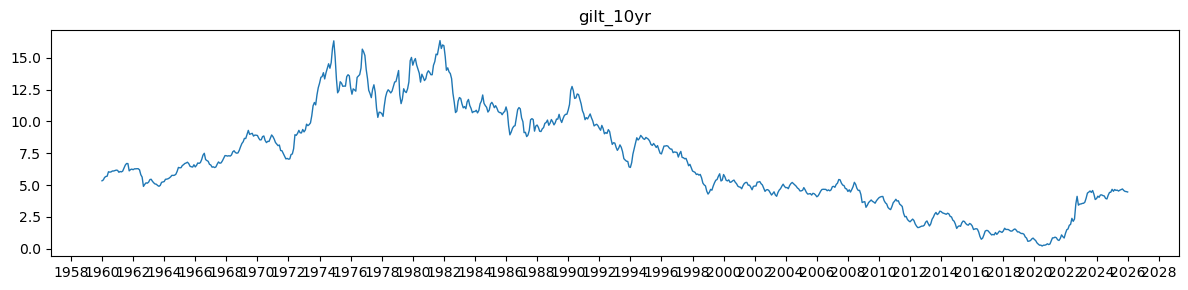


── gbp_usd (FRED) ──────────────────────
  Rows: 14390  |  Nulls: 3.89%  |  Range: 1971-01 → 2026-02
  Gaps: 0  |  Duplicates: 0  |  Grade: B
count    13830.000000
mean         1.675663
std          0.330993
min          1.052000
25%          1.449200
50%          1.608600
75%          1.831000
max          2.644000


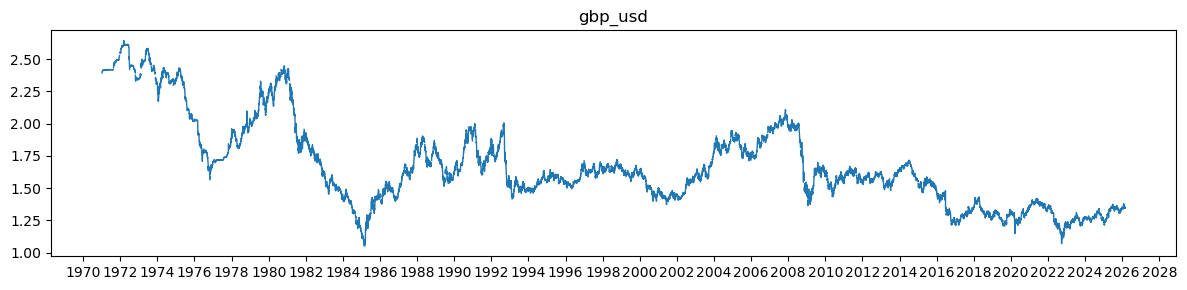


── uk_cpi_oecd (FRED) ──────────────────────
  Rows: 843  |  Nulls: 0.0%  |  Range: 1955-01 → 2025-03
  Gaps: 0  |  Duplicates: 0  |  Grade: A
count    843.000000
mean      53.265582
std       38.708680
min        4.859513
25%        9.891144
50%       52.900000
75%       83.500000
max      136.100000


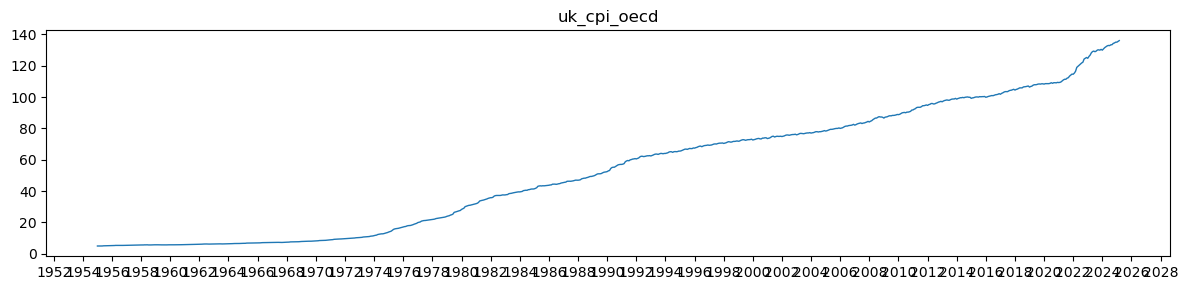



── Quality Summary ───────────────────────────────────────────────────


,series,source,rows,null_pct,date_min,date_max,gaps,duplicates,grade
0,base_rate,BoE,300,0.00,2000-01,2024-12,0,0,A
1,mortgage_approvals,BoE,96,0.00,2000-01,2007-12,0,0,A
2,consumer_credit,BoE,300,0.00,2000-01,2024-12,0,0,A
3,hpi_avg_price,HPI,681,0.00,1968-04,2024-12,0,0,A
4,hpi_sales_volume,HPI,681,65.05,1968-04,2024-12,0,0,FAIL
5,gilt_10yr,FRED,793,0.00,1960-01,2026-01,0,0,A
6,gbp_usd,FRED,14390,3.89,1971-01,2026-02,0,0,B
7,uk_cpi_oecd,FRED,843,0.00,1955-01,2025-03,0,0,A


In [20]:
# ── Load & Inspect All Series ─────────────────────────────────────────────────────────
# Each source has its own quirks — parsing rules are documented inline.
# Output: a dict `series` keyed by series_label → cleaned (date, value) DataFrame.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO

series = {}
qc     = []   # quality check records → will populate the quality log table

# ── Helpers ──────────────────────────────────────────────────────────────────────────

def qc_report(label, source, df):
    if df.empty or df['date'].isna().all():
        print(f'[WARN] {label}: no valid dates — skipping qc_report.')
        return

    null_pct = round(df['value'].isna().mean() * 100, 2)
    dups     = df['date'].duplicated().sum()
    date_min = df['date'].min()
    date_max = df['date'].max()

    # Guard: skip strftime if min/max resolved to NaT
    if pd.isnull(date_min) or pd.isnull(date_max):
        print(f'[WARN] {label}: date range could not be determined.')
        return

    date_min_s = date_min.strftime('%Y-%m')
    date_max_s = date_max.strftime('%Y-%m')

    df_sorted = df.sort_values('date')
    gaps = (df_sorted['date'].diff().dt.days > 32).sum()
    grade = 'A' if null_pct < 1 and gaps == 0 else \
            'B' if null_pct < 5 else \
            'C' if null_pct < 20 else 'FAIL'

    qc.append({
        'series': label, 'source': source, 'rows': len(df),
        'null_pct': null_pct, 'date_min': date_min_s, 'date_max': date_max_s,
        'gaps': gaps, 'duplicates': dups, 'grade': grade,
    })
    print(f'\n── {label} ({source}) ──────────────────────')
    print(f'  Rows: {len(df)}  |  Nulls: {null_pct}%  |  Range: {date_min_s} → {date_max_s}')
    print(f'  Gaps: {gaps}  |  Duplicates: {dups}  |  Grade: {grade}')
    print(df['value'].describe().to_string())


def plot_series(label, df):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df['date'], df['value'], linewidth=1)
    ax.set_title(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.tight_layout()
    plt.show()


# ── Bank of England (TSV, metadata rows at top) ──────────────────────────────────────
# BOE exports have several metadata header rows before the data starts at 'DATE'.
# Slice from that line via StringIO and auto-detect the delimiter.

boe_files = {
    'base_rate':          'boe_base_rate.csv',
    'mortgage_approvals': 'boe_mortgage_approvals.csv',
    'consumer_credit':    'boe_consumer_credit.csv',
    'sme_lending':        'boe_sme_lending.csv',
}

for label, fname in boe_files.items():
    path = DATA_ROOT / 'raw' / 'boe' / fname
    raw  = path.read_text(encoding='utf-8', errors='replace').splitlines()

    header_candidates = [i for i, l in enumerate(raw) if l.strip().upper().startswith('DATE')]
    if not header_candidates:
        print(f'[WARN] Skipping {label}: no DATE header found.')
        continue

    header_idx  = header_candidates[0]
    header_line = raw[header_idx]
    sep = '\t' if '\t' in header_line else ','

    data_text = '\n'.join(raw[header_idx:])
    df = pd.read_csv(StringIO(data_text), sep=sep, na_values=['.', ''])

    if df.shape[1] < 2:
        print(f'[WARN] Skipping {label}: only {df.shape[1]} column(s). Raw header: {header_line!r}')
        continue

    df = df.iloc[:, :2].copy()
    df.columns = ['date', 'value']
    df['date']  = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

    series[label] = df
    qc_report(label, 'BoE', df)
    plot_series(label, df)


# ── ONS (CSV, ~8 metadata header rows, dates like '2024 JAN' or '1988') ─────────────

ons_files = {
    'cpi_inflation':       'ons_cpi_inflation.csv',
    'gdp_growth':          'ons_gdp_growth.csv',
    'unemployment_rate':   'ons_unemployment.csv',
    'avg_weekly_earnings': 'ons_avg_weekly_earnings.csv',
}

for label, fname in ons_files.items():
    path = DATA_ROOT / 'raw' / 'ons' / fname
    raw  = path.read_text(encoding='utf-8', errors='replace').splitlines()

    # ONS data rows start where the first comma-delimited field starts with a 4-digit year
    header_idx = next((i for i, l in enumerate(raw)
                       if l.strip() and l.split(',')[0].strip()[:4].isdigit()), None)

    if header_idx is None:
        print(f'[WARN] {label}: could not detect data start — first 10 lines:')
        print('\n'.join(raw[:10]))
        continue

    data_text = '\n'.join(raw[header_idx:])
    df = pd.read_csv(StringIO(data_text), header=None, na_values=['.', ''])
    df = df.iloc[:, :2].copy()
    df.columns = ['date', 'value']

    # Show sample before parsing so we can diagnose format issues
    print(f'\n[DEBUG] {label} — first 3 raw date values: {df["date"].head(3).tolist()}')

    df['date']  = pd.to_datetime(df['date'].astype(str).str.strip(), format='mixed', errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

    series[label] = df
    qc_report(label, 'ONS', df)
    plot_series(label, df)


# ── UK HPI (large CSV, ~15–32 MB, all regions & metrics) ─────────────────────────────

hpi_path = DATA_ROOT / 'raw' / 'hpi' / 'hpi_full_2024_12.csv'
hpi_raw  = pd.read_csv(hpi_path, low_memory=False)
hpi_raw.columns = hpi_raw.columns.str.strip().str.lower().str.replace(' ', '_')

hpi_uk = hpi_raw[hpi_raw['regionname'].str.lower() == 'united kingdom'].copy()
hpi_uk['date'] = pd.to_datetime(hpi_uk['date'], dayfirst=True, errors='coerce')

for label, col in [('hpi_avg_price', 'averageprice'), ('hpi_sales_volume', 'salesvolume')]:
    if col not in hpi_uk.columns:
        print(f'[WARN] Column "{col}" not found — available: {hpi_uk.columns.tolist()}')
        continue
    df = hpi_uk[['date', col]].rename(columns={col: 'value'}).copy()
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    series[label] = df
    qc_report(label, 'HPI', df)
    plot_series(label, df)


# ── FRED (clean 2-column CSV, '.' = missing) ─────────────────────────────────────────

fred_files = {
    'gilt_10yr':   'fred_gilt_10yr.csv',
    'gbp_usd':     'fred_gbp_usd.csv',
    'uk_cpi_oecd': 'fred_uk_cpi_oecd.csv',
}

for label, fname in fred_files.items():
    path = DATA_ROOT / 'raw' / 'fred' / fname
    df = pd.read_csv(path, na_values=['.', ''])
    df = df.iloc[:, :2].copy()
    df.columns = ['date', 'value']
    df['date']  = pd.to_datetime(df['date'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

    series[label] = df
    qc_report(label, 'FRED', df)
    plot_series(label, df)


# ── Quality Summary Table ─────────────────────────────────────────────────────────────
print('\n\n── Quality Summary ───────────────────────────────────────────────────')
qc_df = pd.DataFrame(qc)[['series', 'source', 'rows', 'null_pct', 'date_min', 'date_max', 'gaps', 'duplicates', 'grade']]
display(qc_df)